In [17]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```

Loading dataset...
Dataset loaded with 200 images across 2 classes.
 - Class 'Diseased': 100 images
 - Class 'Healthy': 100 images


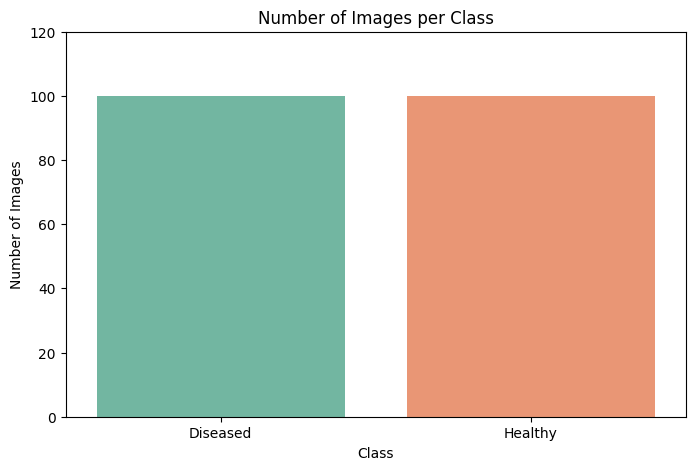

In [18]:
data = []
labels = []
file_name = []
class_counter = {}

target_size = (512, 256) 

for sub_folder in os.listdir("dataset\\"):
    sub_folder_path = os.path.join("dataset\\", sub_folder)
    
    if os.path.isdir(sub_folder_path): 
        sub_folder_files = os.listdir(sub_folder_path)
        class_counter[sub_folder] = 0
        
        for filename in sub_folder_files:
            if class_counter[sub_folder] >= 100:
                break
                
            img_path = os.path.join("dataset\\", sub_folder, filename)
            img = cv.imread(img_path)
            
            if img is not None:
                img_resized = cv.resize(img, target_size)
                
                data.append(img_resized)
                labels.append(sub_folder)
                file_name.append(filename)
                
                class_counter[sub_folder] += 1
        
data = np.array(data)
labels = np.array(labels)

print("Loading dataset...")
print(f"Dataset loaded with {len(data)} images across {len(class_counter)} classes.")
for folder_name, total_files in class_counter.items():
    print(f" - Class '{folder_name}': {total_files} images")

plt.figure(figsize=(8, 5))
sns.barplot(
    x=list(class_counter.keys()),
    y=list(class_counter.values()),
    hue=list(class_counter.keys()),  
    palette="Set2",
    legend=False  
)
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.ylim(0, 120)
plt.show()

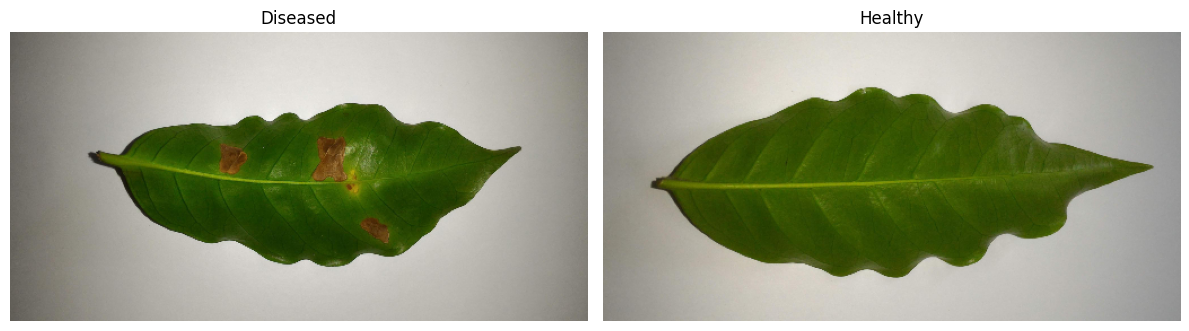

In [19]:
def show_sample_images(images, labels, class_names):
    plt.figure(figsize=(12, 6))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == class_name]
        if len(class_images) > 0:
            plt.subplot(1, 2, i + 1)
            plt.imshow(cv.cvtColor(class_images[10], cv.COLOR_BGR2RGB)) 
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(data, labels, class_counter)

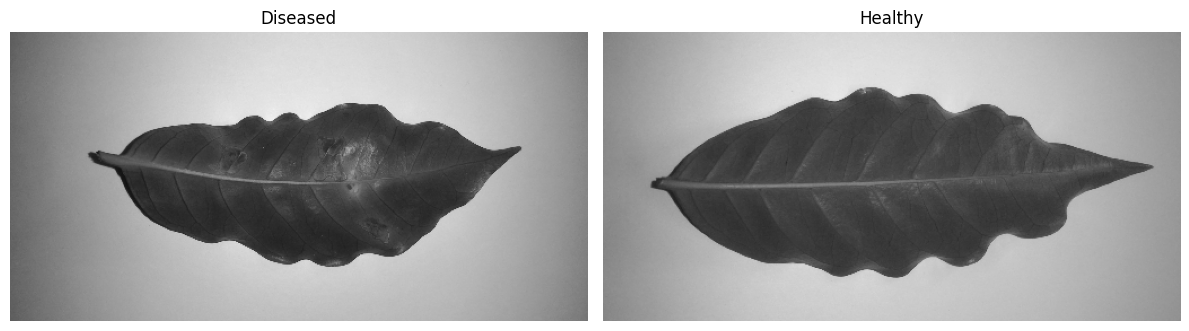

In [20]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_counter)

## Data Augmentation

### Define Augmentation Function


In [21]:
# melakukan augmentasi data
data_augmented = []
labels_augmented = []
paths_augmented = []
file_name_augmented = []
for i in range(len(data)):
	pass

In [22]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  200
Data setelah augmentasi:  0


## Data Preparation

### Define Preprocessing Function


In [23]:
def manual_median_filter(img, size=3):
    height, width = img.shape
    pad = size // 2
    
    padded = np.pad(img, pad, mode='edge').astype(np.uint8)
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.median(region)
    
    return canvas

In [24]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='edge') 
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i : i + size, j : j + size]
            canvas[i, j] = np.sum(region * kernel)
            
    return np.clip(canvas, 0, 255).astype(np.uint8)

k_sharp = np.array([[0, -1, 0], 
                    [-1, 5, -1], 
                    [0, -1, 0]])

img_sharpened = []

In [25]:
def ekualisasi_histogram(citra):
    if citra.dtype != np.uint8:
        if citra.max() <= 1.0:
            citra = (citra * 255).astype(np.uint8)
        else:
            citra = citra.astype(np.uint8)

    panjang, lebar = citra.shape

    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    cdf = np.zeros(256, dtype=int)
    akumulasi = 0
    for i in range(256):
        akumulasi += histogram[i]
        cdf[i] = akumulasi

    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    denominator = (panjang * lebar) - cdf_min
    
    if denominator == 0:
        cdf_norm = cdf
    else:
        cdf_norm = np.round((cdf - cdf_min) / denominator * 255).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

In [26]:
kernel3f1 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

kernel5f1 = np.array([ 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1] 
]) 

In [27]:
def dilasi(image,kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height // 2 
    hasil = np.zeros((height, width), dtype=np.uint8) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil 

In [28]:
def erosi(image, kernel): 
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height): 
                for l in range(k_width): 
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0: 
                        cocok = False 
                        break 
                if not cocok: 
                    break 
            if cocok: 
                hasil[i, j] = 255 
    return hasil

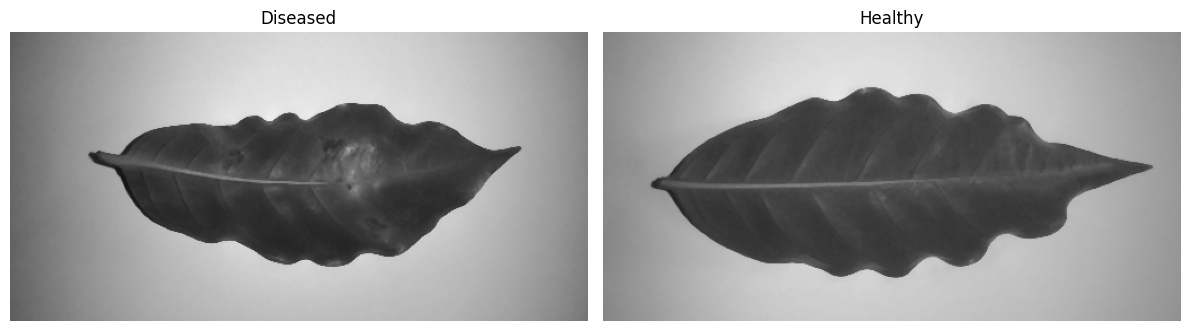

In [29]:
img_median = []

for img in data:
    if len(img.shape) == 3:
        img_grey = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    else:
        img_grey = img
    
    median_res = manual_median_filter(img_grey, size=3)
    img_median.append(median_res)

img_median = np.array(img_median)

show_sample_images(img_median, labels, class_counter)

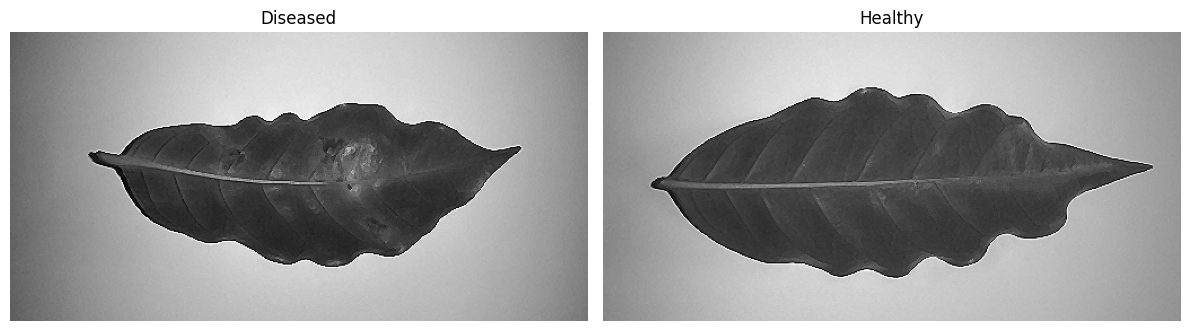

In [30]:
img_sharpened = []

for img in img_median:
    sharp_res = convolution(img, k_sharp)
    img_sharpened.append(sharp_res)

img_sharpened = np.array(img_sharpened)

show_sample_images(img_sharpened, labels, class_counter)

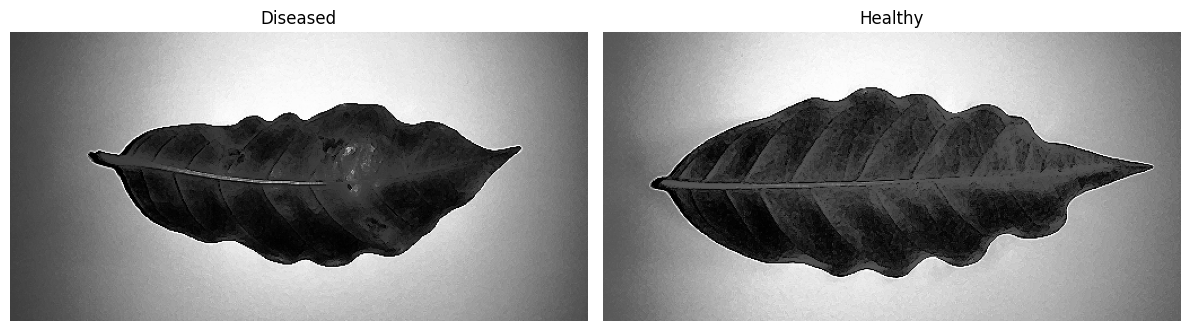

In [31]:
img_equalized = []

for img in img_sharpened:
    eq_res = ekualisasi_histogram(img)
    img_equalized.append(eq_res)

img_equalized = np.array(img_equalized)
show_sample_images(img_equalized, labels, class_counter)

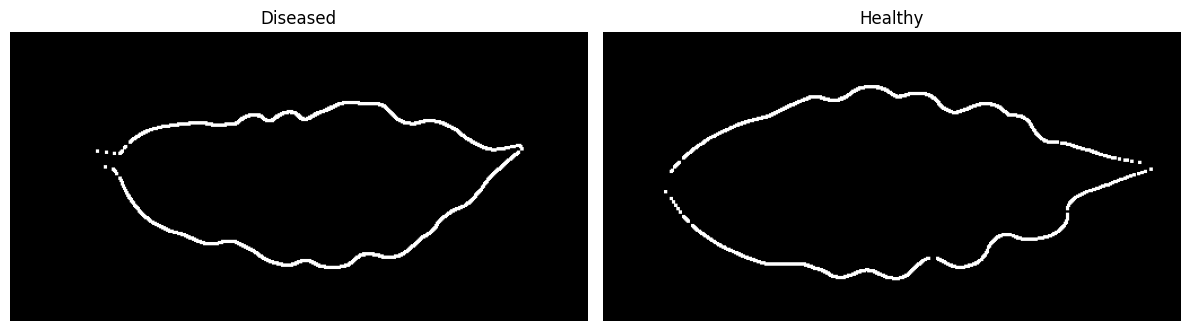

In [32]:
img_dilated = []

for img in img_equalized:
    dil_res = dilasi(img, kernel3f1)
    img_dilated.append(dil_res)

img_dilated = np.array(img_dilated)
show_sample_images(img_dilated, labels, class_counter)

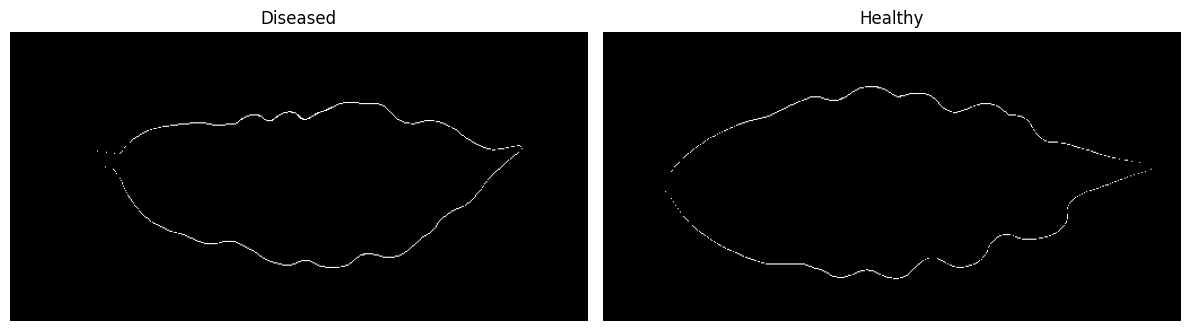

In [33]:
img_eroted = []

for img in img_dilated:
    er_res = erosi(img, kernel3f1)
    img_eroted.append(er_res)

img_eroted = np.array(img_eroted)
show_sample_images(img_eroted, labels, class_counter)

### Feature Extraction

In [34]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [35]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

In [36]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

In [37]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

In [38]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

In [39]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

In [40]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

In [41]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [42]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(img_eroted)):
    D0 = glcm(img_eroted[i], 0)
    D45 = glcm(img_eroted[i], 45)
    D90 = glcm(img_eroted[i], 90)
    D135 = glcm(img_eroted[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [43]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


In [44]:
for i in range(len(img_eroted)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [45]:
for i in range(len(img_eroted)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [46]:
for i in range(len(img_eroted)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [47]:
for i in range(len(img_eroted)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [48]:
for i in range(len(img_eroted)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [49]:
for i in range(len(img_eroted)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [50]:
for i in range(len(img_eroted)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Write the extraction's results to CSV 

In [51]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,100.jpg,Diseased,336.020823,576.868885,656.425781,558.904110,0.994833,0.991129,0.989905,0.991405,...,0.979478,0.980929,0.992144,0.990282,0.989686,0.990419,0.508256,0.159072,0.041235,0.185260
1,101.jpg,Diseased,336.020823,558.904110,656.425781,576.868885,0.994833,0.991405,0.989905,0.991129,...,0.979478,0.980658,0.992144,0.990419,0.989686,0.990282,0.508256,0.185260,0.041235,0.159072
2,102.jpg,Diseased,336.020823,558.904110,656.425781,576.868885,0.994833,0.991405,0.989905,0.991129,...,0.979478,0.980658,0.992144,0.990419,0.989686,0.990282,0.508256,0.185260,0.041235,0.159072
3,103.jpg,Diseased,336.020823,576.868885,656.425781,558.904110,0.994833,0.991129,0.989905,0.991405,...,0.979478,0.980929,0.992144,0.990282,0.989686,0.990419,0.508256,0.159072,0.041235,0.185260
4,104.jpg,Diseased,266.430712,490.039139,559.804688,481.056751,0.995903,0.992464,0.991391,0.992602,...,0.982756,0.983931,0.993593,0.991864,0.991341,0.991933,0.528590,0.136320,0.011438,0.152152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,789.jpg,Healthy,390.698768,787.455969,939.316406,812.407045,0.993992,0.987890,0.985555,0.987506,...,0.970547,0.972416,0.989364,0.986302,0.985163,0.986112,0.604365,0.205686,0.050664,0.180518
196,790.jpg,Healthy,390.698768,787.455969,939.316406,812.407045,0.993992,0.987890,0.985555,0.987506,...,0.970547,0.972416,0.989364,0.986302,0.985163,0.986112,0.604365,0.205686,0.050664,0.180518
197,791.jpg,Healthy,390.698768,812.407045,939.316406,787.455969,0.993992,0.987506,0.985555,0.987890,...,0.970547,0.972791,0.989364,0.986112,0.985163,0.986302,0.604365,0.180518,0.050664,0.205686
198,8.jpg,Healthy,367.833445,620.782779,719.179688,623.776908,0.994343,0.990453,0.988940,0.990407,...,0.977488,0.978902,0.991374,0.989418,0.988680,0.989395,0.510313,0.176778,0.044438,0.172807


<Axes: >

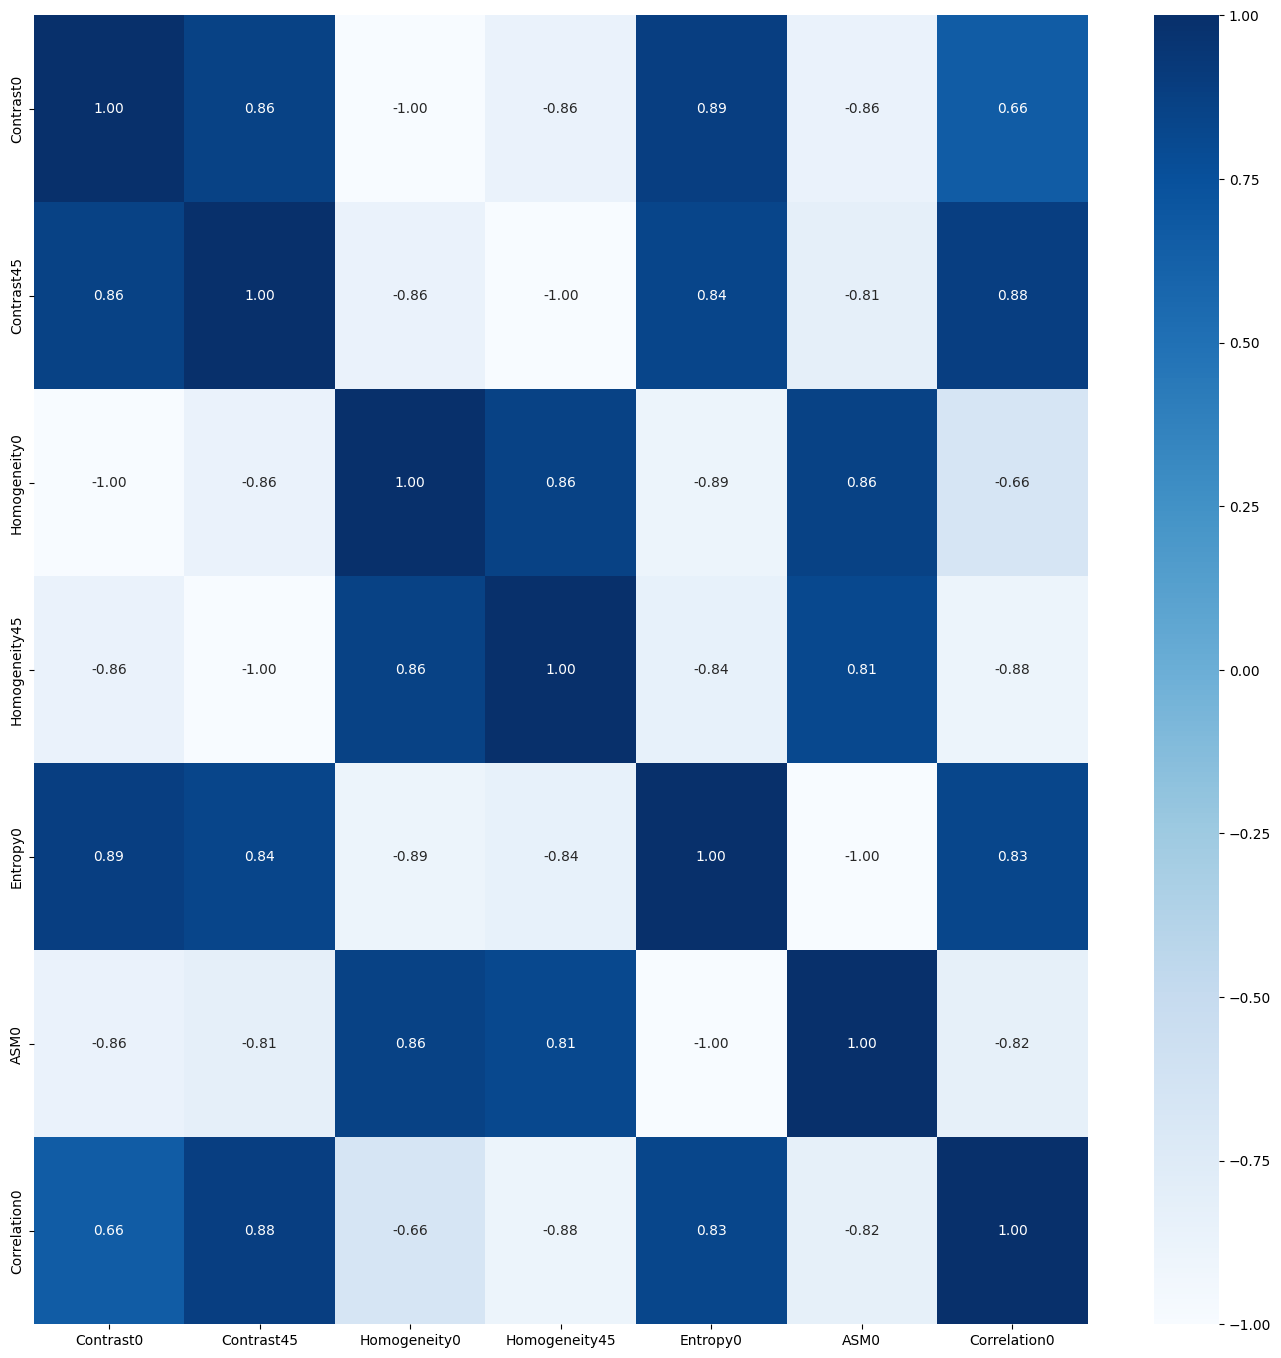

In [52]:
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

## Splitting Data

In [53]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)

(140, 7)
(60, 7)


In [54]:
mean_train = X_train.mean()
std_train = X_train.std()

X_train = (X_train - mean_train) / std_train
X_test = (X_test - mean_train) / std_train

## Modeling

### Define Model

In [55]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [56]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

    Diseased       0.99      0.99      0.99        69
     Healthy       0.99      0.99      0.99        71

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140

[[68  1]
 [ 1 70]]
Accuracy: 0.9857142857142858

------Testing Set------
              precision    recall  f1-score   support

    Diseased       0.96      0.84      0.90        31
     Healthy       0.85      0.97      0.90        29

    accuracy                           0.90        60
   macro avg       0.91      0.90      0.90        60
weighted avg       0.91      0.90      0.90        60

[[26  5]
 [ 1 28]]
Accuracy: 0.9


### Train SVM Classifier

In [57]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Diseased       0.80      0.70      0.74        69
     Healthy       0.74      0.83      0.78        71

    accuracy                           0.76       140
   macro avg       0.77      0.76      0.76       140
weighted avg       0.77      0.76      0.76       140

[[48 21]
 [12 59]]
Accuracy: 0.7642857142857142

------Testing Set------
              precision    recall  f1-score   support

    Diseased       0.74      0.74      0.74        31
     Healthy       0.72      0.72      0.72        29

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.73      0.73      0.73        60

[[23  8]
 [ 8 21]]
Accuracy: 0.7333333333333333


### Train KNN Classifier

In [58]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
              precision    recall  f1-score   support

    Diseased       0.87      0.88      0.88        69
     Healthy       0.89      0.87      0.88        71

    accuracy                           0.88       140
   macro avg       0.88      0.88      0.88       140
weighted avg       0.88      0.88      0.88       140

[[61  8]
 [ 9 62]]
Accuracy: 0.8785714285714286

------Testing Set------
              precision    recall  f1-score   support

    Diseased       0.82      0.74      0.78        31
     Healthy       0.75      0.83      0.79        29

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.79      0.78      0.78        60

[[23  8]
 [ 5 24]]
Accuracy: 0.7833333333333333


## Evaluation With Confusion Matrix

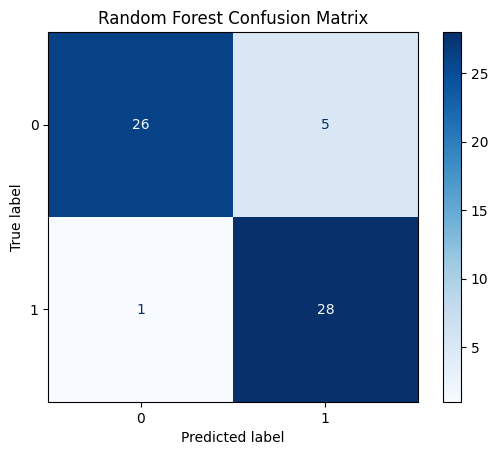

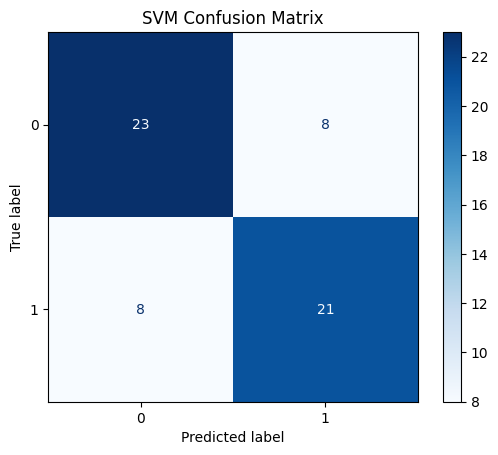

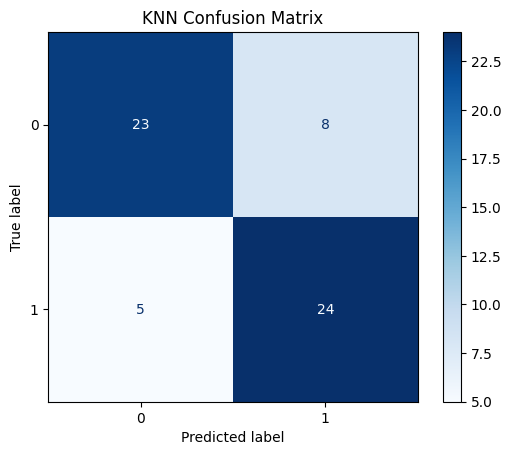

In [59]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")